# 06 — Synthetic benchmark v0.1: fidelity validation

Compares the `central_provisional` pilot's `observed_notices` against the
real BOAMP corpus's calibration tables
(`reports/tables/synthetic_calibration/`), then runs the *existing*
production Layer 1 candidate-generation code
(`boamp.linkage.candidates.generate_pairs_single_key`) on the synthetic
`observed_notices` (via a thin adapter,
`boamp.synthetic.compatibility.adapt_observed_notices_to_sources`) so
candidate-count statistics — an emergent property, never assigned during
generation — can be compared directly.

Per spec, this is diagnostic only: no linkage accuracy claim is made here
(Phase 12), and no synthetic-generation parameter is retuned to make a
preferred linkage method "win".

Every real-vs-synthetic chart below uses the **same two colors** for the
same two series throughout (`COLOR_REAL` / `COLOR_SYNTHETIC`) so color
identity is never re-assigned mid-notebook; the freeze-gate scorecard uses a
separate, fixed status palette (never reused for series identity), since a
pass/fail state is a different kind of "job" than a real-vs-synthetic
comparison.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

from boamp.config import load_config
from boamp.reporting.figures import setup_style
from boamp.synthetic.compatibility import adapt_observed_notices_to_sources
from boamp.linkage.candidates import generate_pairs_single_key

cfg = load_config(PROJECT_ROOT)
setup_style()

TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "synthetic_benchmark" / "v0_1"
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "synthetic_benchmark" / "v0_1"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CALIB_DIR = PROJECT_ROOT / "reports" / "tables" / "synthetic_calibration"

SCENARIO = "central_provisional"
PILOT_DIR = PROJECT_ROOT / "data/processed/synthetic_benchmark/v0_1_provisional" / SCENARIO / "world_001/corruption_001"
observed = pd.read_parquet(PILOT_DIR / "observed_notices.parquet")
clean = pd.read_parquet(PILOT_DIR / "clean_notices.parquet")
buyers = pd.read_parquet(PILOT_DIR / "latent_buyers.parquet")
establishments = pd.read_parquet(PILOT_DIR / "latent_establishments.parquet")
print(f"Loaded {SCENARIO} pilot: {len(observed)} observed notices, {len(buyers)} buyers")

Loaded central_provisional pilot: 9534 observed notices, 2000 buyers


### Chart style

Categorical identity (real vs. synthetic) uses slots 1-2 of the validated
default palette (`references/palette.md` in the `dataviz` skill): blue for
"real corpus", orange for "synthetic pilot" — worst adjacent CVD deltaE 9.1,
comfortably clear of the deltaE>=8 target. Status colors (freeze-gate
scorecard) are a separate, fixed palette never reused for series identity.


In [2]:
COLOR_REAL = "#2a78d6"        # palette slot 1 (blue)  - "real corpus"
COLOR_SYNTHETIC = "#eb6834"   # palette slot 2 (orange) - "synthetic pilot"
COLOR_GRID = "#e3e2dd"
STATUS_COLOR = {
    "PASS": "#0ca30c", "PASS_WITH_LIMITATION": "#fab219",
    "NEEDS_REVISION": "#ec835a", "BLOCKED": "#d03b3b", "NOT_ASSESSED": "#9a9a95",
}
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#2a78d6", "#f0efec", "#e34948"])

def style_axes(ax, horizontal_grid=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(not horizontal_grid)
    ax.grid(axis="y" if horizontal_grid else "x", color=COLOR_GRID, linewidth=0.9, zorder=0)
    ax.set_axisbelow(True)

def real_synth_legend(ax, loc="upper right"):
    handles = [Line2D([0], [0], marker="s", linestyle="", color=COLOR_REAL, markersize=9, label="Real corpus"),
               Line2D([0], [0], marker="s", linestyle="", color=COLOR_SYNTHETIC, markersize=9, label=f"Synthetic ({SCENARIO})")]
    ax.legend(handles=handles, loc=loc, frameon=False)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight", dpi=150)
    fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")

## 1. Volume and schema composition

In [3]:
fidelity_rows = []

def add_fidelity(dimension, real_value, synthetic_value, note=""):
    fidelity_rows.append(dict(dimension=dimension, real_value=real_value,
                               synthetic_value=synthetic_value, note=note))

real_schema_mix = {"LEGACY": 0.874, "EFORMS": 0.126}   # parameter_inventory.csv#schema_family_mix
syn_schema_mix = observed["schema_family"].value_counts(normalize=True).round(3).to_dict()
add_fidelity("schema_family_mix", "LEGACY=87.4%; EFORMS=12.6%", syn_schema_mix)

real_notice_type_mix = {"APPEL_OFFRE": 0.689, "ATTRIBUTION": 0.267, "OTHER": 0.045}   # parameter_inventory.csv#notice_type_mix
syn_notice_type_mix = observed["notice_type_normalized"].value_counts(normalize=True).round(3).to_dict()
add_fidelity("notice_type_mix", "APPEL_OFFRE=68.9%; ATTRIBUTION=26.7%; OTHER=4.5%", syn_notice_type_mix)

print("schema_family_mix  real:", real_schema_mix, " synthetic:", syn_schema_mix)
print("notice_type_mix    real:", real_notice_type_mix, " synthetic:", syn_notice_type_mix)

schema_family_mix  real: {'LEGACY': 0.874, 'EFORMS': 0.126}  synthetic: {'LEGACY': 0.726, 'EFORMS': 0.274}
notice_type_mix    real: {'APPEL_OFFRE': 0.689, 'ATTRIBUTION': 0.267, 'OTHER': 0.045}  synthetic: {'APPEL_OFFRE': 0.725, 'ATTRIBUTION': 0.275}


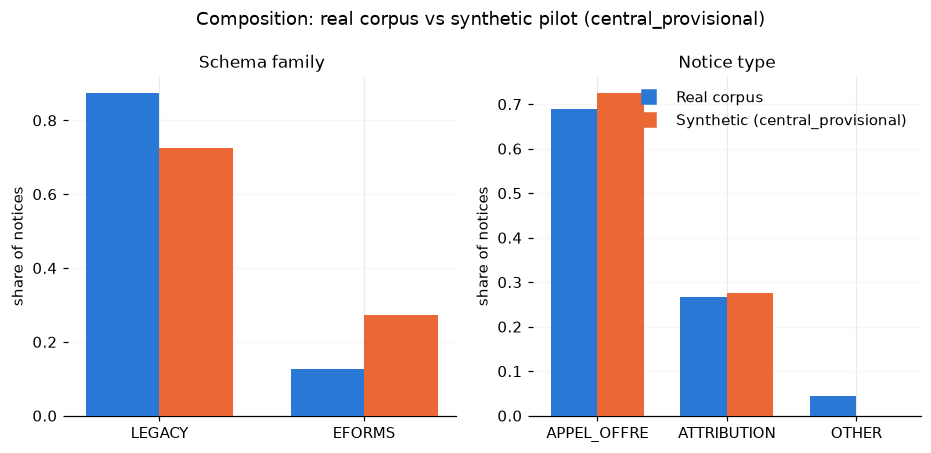

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, real_mix, syn_mix, title in [
    (axes[0], real_schema_mix, syn_schema_mix, "Schema family"),
    (axes[1], real_notice_type_mix, syn_notice_type_mix, "Notice type"),
]:
    categories = list(real_mix)
    x = np.arange(len(categories))
    width = 0.36
    ax.bar(x - width / 2, [real_mix[c] for c in categories], width, color=COLOR_REAL, zorder=3)
    ax.bar(x + width / 2, [syn_mix.get(c, 0.0) for c in categories], width, color=COLOR_SYNTHETIC, zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(categories)
    ax.set_ylabel("share of notices")
    ax.set_title(title)
    style_axes(ax)

real_synth_legend(axes[1])
fig.suptitle(f"Composition: real corpus vs synthetic pilot ({SCENARIO})", y=1.03)
save(fig, "v0_1_composition_real_vs_synthetic")
plt.show()

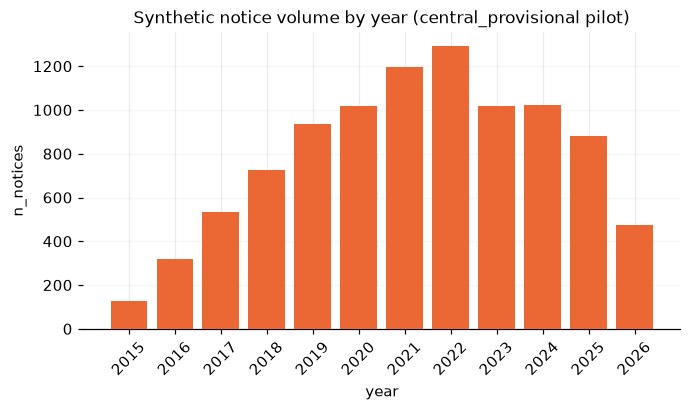

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
year_counts = observed.assign(year=observed["publication_date"].dt.year)["year"].value_counts().sort_index()
ax.bar(year_counts.index.astype(str), year_counts.values, color=COLOR_SYNTHETIC, zorder=3)
ax.set_title(f"Synthetic notice volume by year ({SCENARIO} pilot)")
ax.set_xlabel("year"); ax.set_ylabel("n_notices")
ax.tick_params(axis="x", rotation=45)
style_axes(ax)
save(fig, "v0_1_volume_by_year")
plt.show()

## 2. Buyer activity / concentration

In [6]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n

def lorenz_curve(x):
    x = np.sort(np.asarray(x, dtype=float))
    cum = np.cumsum(x) / x.sum()
    return np.concatenate([[0.0], np.arange(1, len(x) + 1) / len(x)]), np.concatenate([[0.0], cum])

real_gini = 0.832  # calib_buyer_concentration_lorenz.csv / parameter_inventory.csv (real corpus, n=5,268 buyers)
syn_gini = gini(buyers["activity_rate"])
add_fidelity("buyer_activity_gini", real_gini, round(syn_gini, 3),
             "real corpus n=5,268 buyers vs synthetic pilot n=2,000-equivalent-scale buyers (see generate_pilot n_buyers)")
print(f"real Gini = {real_gini}, synthetic Gini = {syn_gini:.3f}")

real Gini = 0.832, synthetic Gini = 0.814


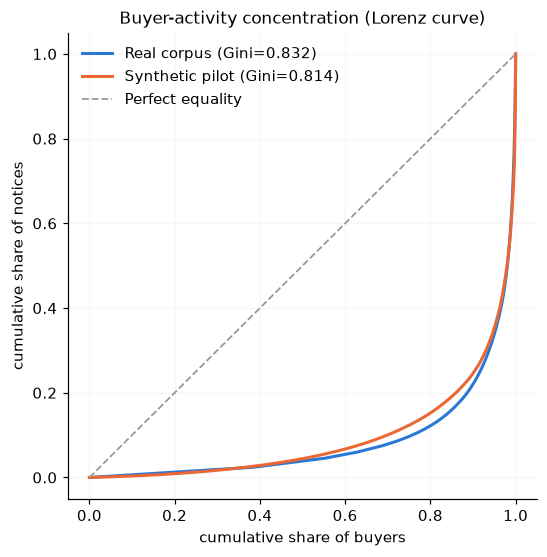

In [7]:
real_lorenz_path = CALIB_DIR / "calib_buyer_concentration_lorenz.csv"
fig, ax = plt.subplots(figsize=(5.5, 5.5))

if real_lorenz_path.exists():
    real_lorenz = pd.read_csv(real_lorenz_path)
    ax.plot(real_lorenz["cum_share_buyers"], real_lorenz["cum_share_notices"],
            color=COLOR_REAL, linewidth=2, label=f"Real corpus (Gini={real_gini})")

syn_x, syn_y = lorenz_curve(buyers["activity_rate"])
ax.plot(syn_x, syn_y, color=COLOR_SYNTHETIC, linewidth=2, label=f"Synthetic pilot (Gini={syn_gini:.3f})")
ax.plot([0, 1], [0, 1], color="#9a9a95", linewidth=1.2, linestyle="--", label="Perfect equality")

ax.set_xlabel("cumulative share of buyers"); ax.set_ylabel("cumulative share of notices")
ax.set_title("Buyer-activity concentration (Lorenz curve)")
ax.legend(loc="upper left", frameon=False)
style_axes(ax, horizontal_grid=False)
ax.grid(color=COLOR_GRID, linewidth=0.9, zorder=0)
save(fig, "v0_1_buyer_lorenz_curve")
plt.show()

In [8]:
establishments_per_buyer = establishments.groupby("buyer_id_true").size()
add_fidelity("establishments_per_buyer_mean", "n/a (not a real-corpus OBSERVABLE table)", round(establishments_per_buyer.mean(), 2),
             "no directly comparable real-corpus table exists (BOAMP does not expose a buyer->establishment hierarchy natively); reported for internal consistency only")
establishments_per_buyer.describe()

count    2000.000000
mean        1.087000
std         0.327849
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
dtype: float64

## 3-6. Identifier, CPV, duration and text availability

In [9]:
real_siret_share = 0.272  # parameter_inventory.csv#siret_vs_name_fallback_share
syn_siret_share = observed["buyer_siret_raw"].notna().mean()
add_fidelity("siret_present_share", real_siret_share, round(syn_siret_share, 3))

real_cpv_missing = 0.1706
syn_cpv_missing = observed["cpv_clean"].isna().mean()
add_fidelity("cpv_missing_rate", real_cpv_missing, round(syn_cpv_missing, 3))

real_cpv_generic = 0.0714
syn_cpv_generic = (observed["cpv_clean"].fillna("").str[2:] == "000000").mean()
add_fidelity("cpv_generic_rate_among_present", real_cpv_generic, round(syn_cpv_generic, 3),
             "real value is conditional on CPV present; synthetic value here is marginal (not yet conditioned) - see freeze gate note")

real_duration_present = 0.1365
syn_duration_present = observed["declared_duration_months"].notna().mean()
add_fidelity("duration_present_rate", real_duration_present, round(syn_duration_present, 3))

real_median_len = 98.0
syn_median_len = float(observed["objet_clean"].dropna().map(len).median())
add_fidelity("median_text_length_chars", real_median_len, syn_median_len)

real_dup_rate = 0.5143
syn_dup_rate = 1 - (observed["objet_clean"].dropna().nunique() / observed["objet_clean"].notna().sum())
add_fidelity("exact_duplicate_template_rate", real_dup_rate, round(syn_dup_rate, 3))

rate_dims = ["siret_present_share", "cpv_missing_rate", "cpv_generic_rate_among_present",
             "duration_present_rate", "exact_duplicate_template_rate"]
rate_real = [real_siret_share, real_cpv_missing, real_cpv_generic, real_duration_present, real_dup_rate]
rate_syn = [syn_siret_share, syn_cpv_missing, syn_cpv_generic, syn_duration_present, syn_dup_rate]
for dim, r, s in zip(rate_dims, rate_real, rate_syn):
    print(f"{dim:35s} real={r:.3f}  synthetic={s:.3f}")

siret_present_share                 real=0.272  synthetic=0.412
cpv_missing_rate                    real=0.171  synthetic=0.170
cpv_generic_rate_among_present      real=0.071  synthetic=0.088
duration_present_rate               real=0.137  synthetic=0.324
exact_duplicate_template_rate       real=0.514  synthetic=0.281


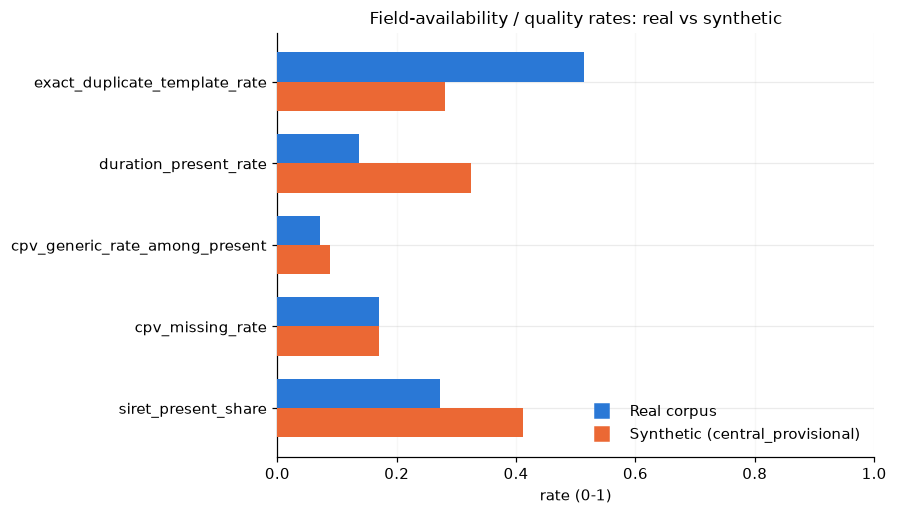

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(rate_dims))
height = 0.36
ax.barh(y + height / 2, rate_real, height, color=COLOR_REAL, zorder=3)
ax.barh(y - height / 2, rate_syn, height, color=COLOR_SYNTHETIC, zorder=3)
ax.set_yticks(y); ax.set_yticklabels(rate_dims)
ax.set_xlabel("rate (0-1)")
ax.set_title("Field-availability / quality rates: real vs synthetic")
ax.set_xlim(0, 1)
style_axes(ax, horizontal_grid=False)
ax.grid(axis="x", color=COLOR_GRID, linewidth=0.9, zorder=0)
real_synth_legend(ax, loc="lower right")
save(fig, "v0_1_rate_comparison")
plt.show()

## 7. Missingness co-occurrence (dependent corruption check)

In [11]:
missing_flags = pd.DataFrame({
    "identifier_missing": observed["buyer_siret_raw"].isna() & observed["buyer_siren_raw"].isna(),
    "cpv_missing": observed["cpv_clean"].isna(),
    "duration_missing": observed["declared_duration_months"].isna(),
})
phi = missing_flags.astype(int).corr()
add_fidelity("missingness_phi_identifier_cpv", "see calib_missingness_phi_matrix.csv (real)",
             round(phi.loc["identifier_missing", "cpv_missing"], 3),
             "positive correlation here evidences the latent quality-class dependent-corruption mechanism (missingness.py)")
phi

,identifier_missing,cpv_missing,duration_missing
identifier_missing,1.000000,0.121423,0.282120
cpv_missing,0.121423,1.000000,0.148154
duration_missing,0.282120,0.148154,1.000000


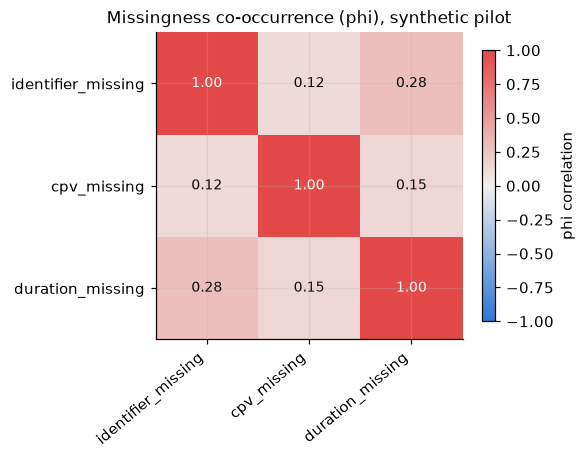

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(phi.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(phi.columns))); ax.set_xticklabels(phi.columns, rotation=40, ha="right")
ax.set_yticks(range(len(phi.index))); ax.set_yticklabels(phi.index)
for i in range(len(phi.index)):
    for j in range(len(phi.columns)):
        v = phi.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "#0b0b0b", fontsize=9)
ax.set_title("Missingness co-occurrence (phi), synthetic pilot")
fig.colorbar(im, ax=ax, shrink=0.8, label="phi correlation")
save(fig, "v0_1_missingness_phi_heatmap")
plt.show()

## 8. Notice-family size

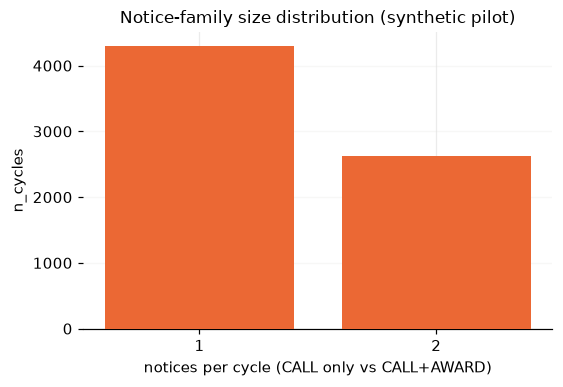

In [13]:
fam = pd.read_parquet(PILOT_DIR / "notice_family_membership.parquet")
fam_size = fam.groupby("cycle_id_true").size()
add_fidelity("notice_family_size_mean", "see notice_family_size_distribution.csv (real, provisional-family-based)", round(fam_size.mean(), 2))

fig, ax = plt.subplots(figsize=(5.5, 3.5))
counts = fam_size.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color=COLOR_SYNTHETIC, zorder=3)
ax.set_xlabel("notices per cycle (CALL only vs CALL+AWARD)"); ax.set_ylabel("n_cycles")
ax.set_title("Notice-family size distribution (synthetic pilot)")
style_axes(ax)
save(fig, "v0_1_notice_family_size")
plt.show()

## 9. Candidate-environment fidelity (Phase 12 compatibility check)

Runs the **existing, unmodified** Layer 1 candidate-generation code on the
synthetic `observed_notices` (via a thin schema adapter) so candidate-count
statistics — an emergent output, never set during generation — can be
compared to the real corpus's own candidate-environment numbers. This
proves the production linkage code can consume `observed_notices.parquet`
and gives a first-pass fidelity read; it is **not** a linkage-accuracy
claim (no synthetic ground truth is used by the candidate generator, and no
generator parameter is tuned based on this result).


In [14]:
sources_adapted = adapt_observed_notices_to_sources(observed)
pairs, window_months = generate_pairs_single_key(sources_adapted, cfg, verbose=True)

cand_per_source = pairs[pairs["candidate_rank"] == 1]["n_candidates_for_source"]
n_eligible = (sources_adapted["buyer_key_type"] != "MISSING").sum()
n_with_candidates = pairs["source_notice_id"].nunique()
zero_candidate_rate = 1 - (n_with_candidates / n_eligible)

print(f"window_months used: {window_months}")
print(f"eligible sources (buyer_key present): {n_eligible}")
print(f"sources with >=1 candidate: {n_with_candidates}")
print(f"synthetic zero-candidate rate: {zero_candidate_rate:.1%}  (real corpus, USE_AS_FIDELITY_TARGET: 60.9%)")
print(f"synthetic candidates-per-source median/p90: {cand_per_source.median():.0f} / {cand_per_source.quantile(0.9):.0f}  "
      f"(real corpus: median=3, p90=12)")

add_fidelity("zero_candidate_source_rate", 0.609, round(zero_candidate_rate, 3),
             "real value is Layer 1 production (algorithm-conditioned); synthetic value uses the same production candidate-generation code on synthetic data, per Phase 9/12")
add_fidelity("candidates_per_source_median", 3, round(cand_per_source.median()))
add_fidelity("candidates_per_source_p90", 12, round(cand_per_source.quantile(0.9)))

Eligible sources: 9534; median observed duration 12.0m -> temporal window 6m


Generated 29821 Layer 1 candidate pairs (3399 sources with >=1 candidate)
window_months used: 6
eligible sources (buyer_key present): 9534
sources with >=1 candidate: 3399
synthetic zero-candidate rate: 64.3%  (real corpus, USE_AS_FIDELITY_TARGET: 60.9%)
synthetic candidates-per-source median/p90: 2 / 29  (real corpus: median=3, p90=12)


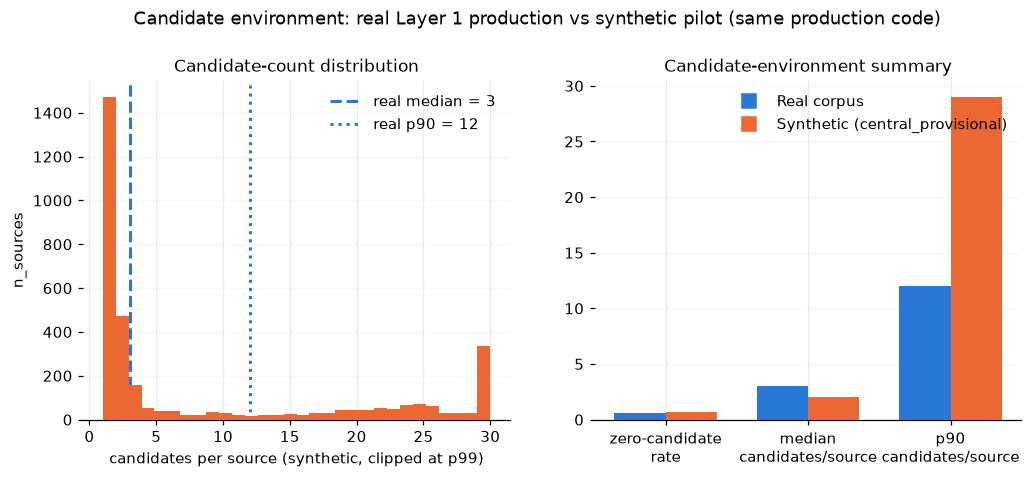

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
cap = cand_per_source.quantile(0.99)
ax.hist(cand_per_source.clip(upper=cap), bins=30, color=COLOR_SYNTHETIC, zorder=3)
ax.axvline(3, color=COLOR_REAL, linewidth=2, linestyle="--", label="real median = 3")
ax.axvline(12, color=COLOR_REAL, linewidth=2, linestyle=":", label="real p90 = 12")
ax.set_xlabel("candidates per source (synthetic, clipped at p99)"); ax.set_ylabel("n_sources")
ax.set_title("Candidate-count distribution")
ax.legend(frameon=False)
style_axes(ax)

ax = axes[1]
labels = ["zero-candidate\nrate", "median\ncandidates/source", "p90\ncandidates/source"]
real_vals = [0.609, 3, 12]
syn_vals = [zero_candidate_rate, cand_per_source.median(), cand_per_source.quantile(0.9)]
x = np.arange(len(labels)); width = 0.36
ax_twin_note = ax.bar(x - width / 2, real_vals, width, color=COLOR_REAL, zorder=3)
ax.bar(x + width / 2, syn_vals, width, color=COLOR_SYNTHETIC, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Candidate-environment summary")
style_axes(ax)
real_synth_legend(ax)

fig.suptitle("Candidate environment: real Layer 1 production vs synthetic pilot (same production code)", y=1.04)
save(fig, "v0_1_candidate_environment")
plt.show()

## 10. Export fidelity tables

In [16]:
fidelity_df = pd.DataFrame(fidelity_rows)
fidelity_df.to_csv(TABLES_DIR / "v0_1_fidelity_summary.csv", index=False)
fidelity_df

,dimension,real_value,synthetic_value,note
0,schema_family_mix,LEGACY=87.4%; EFORMS=12.6%,"{'LEGACY': 0.726, 'EFORMS': 0.274}",
1,notice_type_mix,APPEL_OFFRE=68.9%; ATTRIBUTION=26.7%; OTHER=4.5%,"{'APPEL_OFFRE': 0.725, 'ATTRIBUTION': 0.275}",
2,buyer_activity_gini,0.832,0.814,"real corpus n=5,268 buyers vs synthetic pilot ..."
3,establishments_per_buyer_mean,n/a (not a real-corpus OBSERVABLE table),1.09,no directly comparable real-corpus table exist...
4,siret_present_share,0.272,0.412,
5,cpv_missing_rate,0.1706,0.17,
6,cpv_generic_rate_among_present,0.0714,0.088,real value is conditional on CPV present; synt...
7,duration_present_rate,0.1365,0.324,
8,median_text_length_chars,98.0,120.0,
9,exact_duplicate_template_rate,0.5143,0.281,


## 11. Fidelity scorecard (freeze gate)

Status colors are reserved for pass/fail state and never reused for series
identity elsewhere in this notebook (the real-vs-synthetic charts above use
`COLOR_REAL`/`COLOR_SYNTHETIC` throughout, never these).


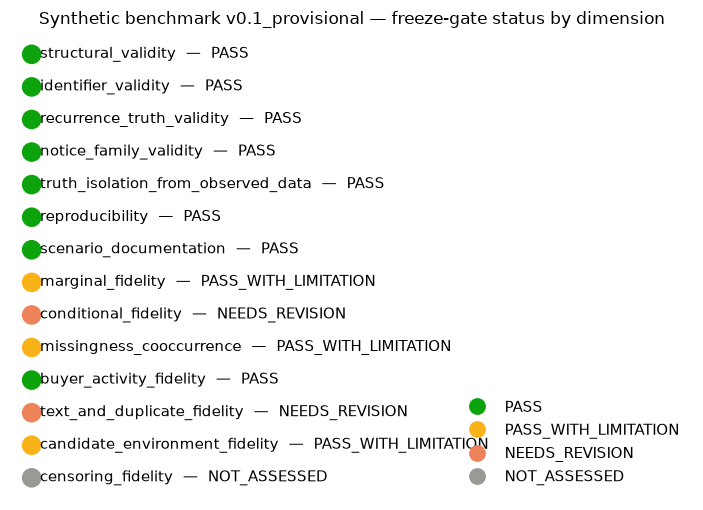

In [17]:
gate = pd.read_csv(PROJECT_ROOT / "reports/tables/synthetic_benchmark/v0_1/benchmark_freeze_gate.csv")

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(gate))[::-1]
colors = gate["status"].map(STATUS_COLOR)
ax.scatter(np.zeros(len(gate)), y, color=colors, s=140, zorder=3)
for yi, dim, status in zip(y, gate["dimension"], gate["status"]):
    ax.text(0.02, yi, f"{dim}  —  {status}", va="center", fontsize=9.5)
ax.set_xlim(-0.05, 1.6)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Synthetic benchmark v0.1_provisional — freeze-gate status by dimension")

legend_handles = [Line2D([0], [0], marker="o", linestyle="", color=c, markersize=10, label=s)
                   for s, c in STATUS_COLOR.items() if s in set(gate["status"])]
ax.legend(handles=legend_handles, loc="lower right", frameon=False, ncol=1)
save(fig, "v0_1_freeze_gate_scorecard")
plt.show()

## 12. Discrepancy summary

Read together with `reports/tables/synthetic_benchmark/v0_1/benchmark_freeze_gate.csv`
and `reports/generated/synthetic_benchmark/v0_1_fidelity_report.md`.


In [18]:
print(fidelity_df.to_string(index=False))

                     dimension                                                               real_value                              synthetic_value                                                                                                                                                           note
             schema_family_mix                                               LEGACY=87.4%; EFORMS=12.6%           {'LEGACY': 0.726, 'EFORMS': 0.274}                                                                                                                                                               
               notice_type_mix                         APPEL_OFFRE=68.9%; ATTRIBUTION=26.7%; OTHER=4.5% {'APPEL_OFFRE': 0.725, 'ATTRIBUTION': 0.275}                                                                                                                                                               
           buyer_activity_gini                                              